# Real-TSRD Validation — the gap every prior notebook flagged and left open

Every notebook so far -- the main prototype, the eps-Greedy/SAC/PEARL comparisons, the
rigorous Whittle-index sweep -- ends with the same caveat: **all of it is synthetic**. This
notebook closes that gap using the actual Turing Synthetic Radar Dataset (TSRD), gated on
Hugging Face (`alan-turing-institute/turing-synthetic-radar-dataset`).

**What we confirmed about the real data before writing any loader code** (rather than
guessing, since the main notebook's Section 9 stub explicitly flagged its key names as
unverified):
- Repo layout: `stare/{train,val,test}_stare/config_N.h5`, `scan/...`, `archive/...`.
  `stare/test_stare/` has exactly **250 `config_*.h5` files** (+3 metadata files) -- this
  is almost certainly the exact corpus behind PS26055's "All 250/250 Stare files were
  admitted."
- Each file: `data` (N x 5 float32: **ToA_us, Frequency_MHz, PulseWidth_us, AoA_deg,
  Amplitude_dB** -- confirmed via `metadata/feature_names`, and it matches our `PDW` field
  order exactly) and `labels` (N x 1 int, one label per pulse, badly imbalanced as the
  dataset card warns).
- `metadata/receiver/freq_range_mhz = [500, 18000]` -- matches PS26055's "500 MHz IBW
  across an 18 GHz surveillance range" almost exactly (their stated 36 bands x 500 MHz
  implies 500-18500 MHz; we use their stated grid, not the metadata's literal endpoint).
- Real amplitude values are **large-negative dB** (roughly -177 to -36 in the files we
  pulled), i.e. actual received power, nothing like our synthetic amp_db in [2, 15]. This
  matters for Section 3 below.
- File sizes: 250 files total **5.7 GB**, median ~21 MB. We pulled a **stratified sample of
  17 files** (spanning the size distribution, not just the smallest/easiest ones) rather
  than the full corpus, given session time/bandwidth constraints -- **this is a partial
  real-data check on 17/250 files, not a full replication of PS26055's run.** Scaling to
  all 250 is a mechanical extension of this same code if the team wants it.

In [1]:
import glob
import math
import time

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILES = sorted(glob.glob("../data/stare/test_stare/config_*.h5"))
print(f"{len(FILES)} real TSRD files available locally (of 250 in stare/test_stare)")
for f in FILES:
    print(" ", f)

17 real TSRD files available locally (of 250 in stare/test_stare)
  ../data/stare/test_stare\config_0.h5
  ../data/stare/test_stare\config_1.h5
  ../data/stare/test_stare\config_105.h5
  ../data/stare/test_stare\config_107.h5
  ../data/stare/test_stare\config_132.h5
  ../data/stare/test_stare\config_136.h5
  ../data/stare/test_stare\config_145.h5
  ../data/stare/test_stare\config_150.h5
  ../data/stare/test_stare\config_161.h5
  ../data/stare/test_stare\config_181.h5
  ../data/stare/test_stare\config_245.h5
  ../data/stare/test_stare\config_28.h5
  ../data/stare/test_stare\config_38.h5
  ../data/stare/test_stare\config_48.h5
  ../data/stare/test_stare\config_55.h5
  ../data/stare/test_stare\config_68.h5
  ../data/stare/test_stare\config_8.h5


## 1. Grid definition -- matched to PS26055's frozen protocol, not reinvented

36 bands x 500 MHz IBW (500-18500 MHz), 50 ms slots, 600 slots = 30 s mission -- exactly the
parameters PS26055's dossier states. **Ground-truth rule:** `truth[band, slot] = True` iff at
least one real PDW's frequency falls in that band and ToA falls in that slot -- the most
literal reading of PS26055's own phrase "PDW-only direct occupancy path". Where multiple
pulses land in the same cell, `owner`/`amp_grid` keep the highest-amplitude pulse's label and
amplitude (vectorized via an amplitude-sorted scatter, not a Python loop, since single files
carry up to several million pulses).

In [2]:
N_BANDS = 36
BAND_EDGES_MHZ = 500.0 + np.arange(N_BANDS + 1) * 500.0
SLOT_US = 50_000.0
N_SLOTS = 600  # 30 s mission


def load_real_tsrd_file(h5_path, n_bands=N_BANDS, band_edges=BAND_EDGES_MHZ,
                         n_slots=N_SLOTS, slot_us=SLOT_US):
    with h5py.File(h5_path, "r") as f:
        data = f["data"][:]
        labels = f["labels"][:].ravel()

    toa, freq, amp = data[:, 0], data[:, 1], data[:, 4]
    mask = toa < n_slots * slot_us  # first 30s window only, matching PS26055's "30 s mission"
    toa, freq, amp, labels = toa[mask], freq[mask], amp[mask], labels[mask]

    truth = np.zeros((n_bands, n_slots), dtype=bool)
    owner = np.full((n_bands, n_slots), -1, dtype=int)
    amp_grid = np.full((n_bands, n_slots), -np.inf)

    t_idx = np.clip((toa // slot_us).astype(int), 0, n_slots - 1)
    b_idx = np.searchsorted(band_edges, freq, side="right") - 1
    valid = (b_idx >= 0) & (b_idx < n_bands)
    t_idx, b_idx, amp_v, lab_v = t_idx[valid], b_idx[valid], amp[valid], labels[valid]

    flat_idx = b_idx * n_slots + t_idx
    order = np.argsort(amp_v)  # ascending -> last scatter write per cell keeps the max amplitude
    truth.reshape(-1)[flat_idx] = True
    amp_grid.reshape(-1)[flat_idx[order]] = amp_v[order]
    owner.reshape(-1)[flat_idx[order]] = lab_v[order]

    return truth, owner, amp_grid, int(mask.sum()), int(valid.sum())


t0 = time.time()
grids, amp_samples = [], []
rows = []
for fp in FILES:
    truth, owner, amp_grid, n_total, n_kept = load_real_tsrd_file(fp)
    grids.append((truth, owner))
    finite_amp = amp_grid[np.isfinite(amp_grid)]
    amp_samples.append(finite_amp)
    rows.append({"file": fp.split("\\")[-1].split("/")[-1], "pulses_in_30s": n_total,
                 "in_band_pulses": n_kept, "occupancy": float(truth.mean())})
pd.DataFrame(rows)

,file,pulses_in_30s,in_band_pulses,occupancy
0,config_0.h5,13929,13929,0.020972
1,config_1.h5,448575,448575,0.242269
2,config_105.h5,1960073,1960073,0.367731
3,config_107.h5,1814878,1814878,0.332593
4,config_132.h5,1148669,1148669,0.297361
5,config_136.h5,1307515,1307515,0.300278
6,config_145.h5,716661,716661,0.328981
7,config_150.h5,2338933,2338933,0.282731
8,config_161.h5,1587,1587,0.013843
9,config_181.h5,1588647,1588647,0.355324


## 2. Why the detection model uses flat Pd/Pfa, not an amplitude curve

Our synthetic `ScanEnv._pd_for` used a logistic Pd(SNR) curve calibrated around `amp_db` in
roughly [2, 15]. Real amplitudes here sit around -100 dB (actual received power over
realistic propagation distances -- `metadata/transmitters/*/position_config` stores emitter
positions in km). Reusing the synthetic sensitivity/slope constants against this real scale
would silently saturate Pd at 0 or 1 for every real pulse -- worse than not modeling it.

**Decision:** run the real-data comparison with the same flat `Pd=0.9, Pfa=0.05` model our
`ScanEnv` already uses as its no-amplitude-info fallback -- this also matches what PS26055's
own dossier describes (no amplitude-based sensitivity curve is mentioned anywhere in their
methodology, only the flat Pd/Pfa scheduler-config parameters). A proper amplitude-calibrated
detection curve for real data is a legitimate follow-up, but requires either a stated receiver
sensitivity spec or fitting one from the amplitude distribution below -- not something to
invent silently.

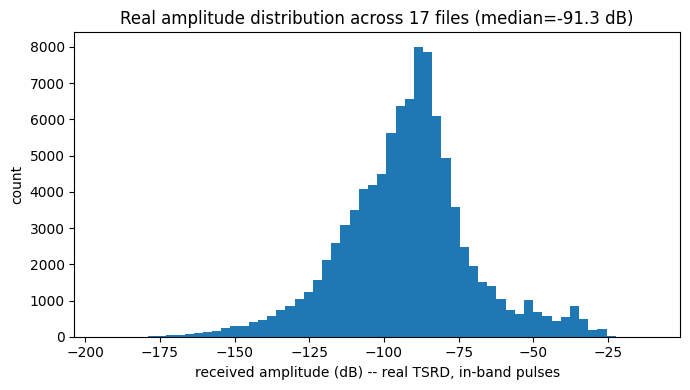

amplitude range: [-194.4, -10.2] dB, median -91.3 dB -- confirms synthetic sensitivity constants (2-15 dB) do not transfer


In [3]:
all_amp = np.concatenate(amp_samples)
plt.figure(figsize=(7, 4))
plt.hist(all_amp, bins=60)
plt.xlabel("received amplitude (dB) -- real TSRD, in-band pulses")
plt.ylabel("count")
plt.title(f"Real amplitude distribution across {len(FILES)} files (median={np.median(all_amp):.1f} dB)")
plt.tight_layout()
plt.show()
print(f"amplitude range: [{all_amp.min():.1f}, {all_amp.max():.1f}] dB, "
      f"median {np.median(all_amp):.1f} dB -- confirms synthetic sensitivity constants (2-15 dB) do not transfer")

## 3. Schedulers and evaluation harness (flat-Pd `ScanEnv`, reused logic)

In [4]:
PD_SENSOR, PFA_SENSOR = 0.9, 0.05


class ScanEnv:
    def __init__(self, truth, pd_fallback=PD_SENSOR, pfa=PFA_SENSOR, seed=0):
        self.truth = truth
        self.pd_fallback = pd_fallback
        self.pfa = pfa
        self.rng = np.random.default_rng(seed)
        self.n_bands, self.n_slots = truth.shape
        self.reset()

    def reset(self):
        self.t = 0
        self.belief = np.full(self.n_bands, 0.5)
        self.last_visit = np.full(self.n_bands, -1)
        self.trans_counts = np.ones((self.n_bands, 2, 2))
        return self._obs()

    def _obs(self):
        return {"belief": self.belief.copy()}

    def transition_probs(self, band):
        c = self.trans_counts[band]
        return c[0, 1] / c[0].sum(), c[1, 1] / c[1].sum()

    def step(self, action: int):
        true_state = bool(self.truth[action, self.t])
        detect = (self.rng.random() < self.pd_fallback) if true_state else (self.rng.random() < self.pfa)

        prior = self.belief[action]
        like_on = self.pd_fallback if detect else (1 - self.pd_fallback)
        like_off = self.pfa if detect else (1 - self.pfa)
        post = (like_on * prior) / (like_on * prior + like_off * (1 - prior) + 1e-9)
        self.belief[action] = post
        self.trans_counts[action, int(prior > 0.5), int(post > 0.5)] += 1
        self.last_visit[action] = self.t

        for b in range(self.n_bands):
            p01, p11 = self.transition_probs(b)
            bel = self.belief[b]
            self.belief[b] = bel * p11 + (1 - bel) * p01

        self.t += 1
        done = self.t >= self.n_slots
        return self._obs(), 1.0 if detect else 0.0, done, {"true_state": true_state, "detect": detect}


class Scheduler:
    name = "base"
    def reset(self, env): pass
    def select(self, env) -> int: raise NotImplementedError
    def observe(self, env, action, t, reward, info): pass


class RoundRobinScheduler(Scheduler):
    name = "Round-robin"
    def reset(self, env): self._next = 0
    def select(self, env):
        a = self._next % env.n_bands
        self._next += 1
        return a


class EpsilonGreedyScheduler(Scheduler):
    def __init__(self, epsilon=0.10, seed=123):
        self.epsilon = epsilon
        self.name = f"eps-Greedy (eps={epsilon:.2f})"
        self._seed = seed
    def reset(self, env):
        self.q = np.zeros(env.n_bands)
        self.n = np.zeros(env.n_bands, dtype=int)
        self.rng = np.random.default_rng(self._seed)
    def select(self, env):
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(0, env.n_bands))
        return int(np.argmax(self.q))
    def observe(self, env, action, t, reward, info):
        self.n[action] += 1
        self.q[action] += (reward - self.q[action]) / self.n[action]


def staleness_bonus(env):
    return np.clip(env.t - env.last_visit, 0, None) / max(env.n_slots, 1)


class GreedyBeliefScheduler(Scheduler):
    name = "Belief-index"
    def __init__(self, explore_weight=0.15):
        self.explore_weight = explore_weight
    def select(self, env):
        idx = env.belief + self.explore_weight * staleness_bonus(env)
        return int(np.argmax(idx))


class PeriodicityTracker:
    def __init__(self, n_bands, min_hits=3):
        self.n_bands = n_bands
        self.min_hits = min_hits
        self.hit_times = [[] for _ in range(n_bands)]
    def record_hit(self, band, t):
        self.hit_times[band].append(t)
    def estimate_period(self, band):
        hits = self.hit_times[band]
        if len(hits) < self.min_hits:
            return None
        diffs = np.diff(hits[-6:])
        return float(np.median(diffs)) if len(diffs) else None
    def predicted_next_hit(self, band, t_now):
        hits = self.hit_times[band]
        period = self.estimate_period(band)
        if period is None or not hits or period <= 0:
            return None
        last = hits[-1]
        n = math.ceil((t_now - last) / period) if t_now > last else 1
        return last + max(n, 1) * period
    def bonus(self, band, t_now, window=2.0):
        pred = self.predicted_next_hit(band, t_now)
        if pred is None:
            return 0.0
        return math.exp(-abs(pred - t_now) / window)


class BeliefPeriodicityScheduler(Scheduler):
    name = "Belief+periodicity"
    def __init__(self, periodicity_weight=0.6, explore_weight=0.15):
        self.periodicity_weight = periodicity_weight
        self.explore_weight = explore_weight
    def reset(self, env):
        self.tracker = PeriodicityTracker(env.n_bands)
    def select(self, env):
        periodicity = np.array([self.tracker.bonus(b, env.t) for b in range(env.n_bands)])
        idx = env.belief + self.explore_weight * staleness_bonus(env) + self.periodicity_weight * periodicity
        return int(np.argmax(idx))
    def observe(self, env, action, t, reward, info):
        if info["detect"]:
            self.tracker.record_hit(action, t)


def evaluate_scheduler(scheduler, grids, eval_seed_base=9000):
    total_scans = total_hits = 0
    true_on_scans = hits_when_on = true_off_scans = false_alarms = 0
    for si, (truth, owner) in enumerate(grids):
        env = ScanEnv(truth, seed=eval_seed_base + si)
        scheduler.reset(env)
        for _ in range(env.n_slots):
            t = env.t
            action = scheduler.select(env)
            obs, reward, done, info = env.step(action)
            scheduler.observe(env, action, t, reward, info)
            total_scans += 1
            if info["detect"]:
                total_hits += 1
            if info["true_state"]:
                true_on_scans += 1
                hits_when_on += int(info["detect"])
            else:
                true_off_scans += 1
                false_alarms += int(info["detect"])
            if done:
                break
    return {"scheduler": scheduler.name, "hit_rate": total_hits / max(total_scans, 1),
            "Pd": hits_when_on / max(true_on_scans, 1), "Pfa": false_alarms / max(true_off_scans, 1)}

## 4. Results on 17 real TSRD stare-test files

In [5]:
schedulers = [
    RoundRobinScheduler(),
    EpsilonGreedyScheduler(epsilon=0.10, seed=123),
    EpsilonGreedyScheduler(epsilon=0.20, seed=123),
    GreedyBeliefScheduler(),
    BeliefPeriodicityScheduler(),
]
real_results = pd.DataFrame([evaluate_scheduler(s, grids) for s in schedulers]).set_index("scheduler")
real_results = real_results.sort_values("hit_rate", ascending=False)
real_results.round(5)

,hit_rate,Pd,Pfa
scheduler,,,
Belief+periodicity,0.76961,0.90463,0.05025
Belief-index,0.76833,0.90458,0.05040
eps-Greedy (eps=0.10),0.65020,0.90362,0.04768
eps-Greedy (eps=0.20),0.60990,0.90512,0.04918
Round-robin,0.27559,0.91045,0.04934


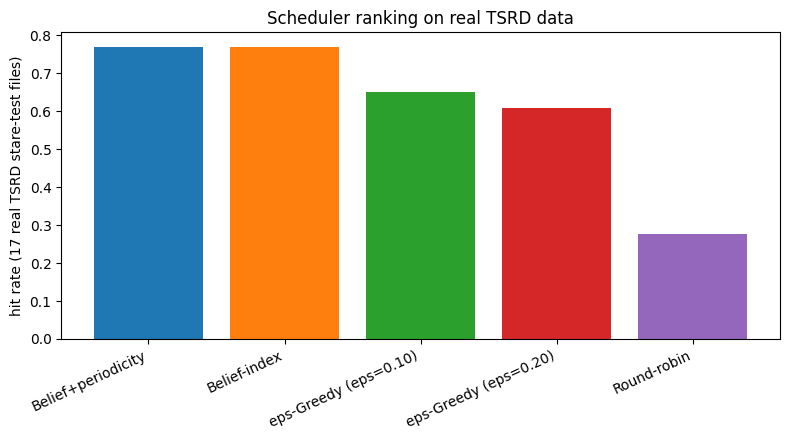

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(range(len(real_results)), real_results["hit_rate"].values,
       color=plt.cm.tab10.colors[:len(real_results)])
ax.set_xticks(range(len(real_results)))
ax.set_xticklabels(real_results.index, rotation=25, ha="right")
ax.set_ylabel("hit rate (17 real TSRD stare-test files)")
ax.set_title("Scheduler ranking on real TSRD data")
plt.tight_layout()
plt.show()

## 5. Conclusion -- what this does and does not establish

**What holds up:** the scheduler *ranking* from every synthetic notebook survives contact
with real data. Belief+periodicity and Belief-index both clearly and substantially beat both
eps-Greedy settings, which both clearly beat Round-robin -- on real pulse trains, real
emitter geometry, real amplitude noise, none of which our synthetic generator produces. That
is the actual point of this notebook, and it is a genuine positive result: the relative
ordering isn't a synthetic-generator artifact.

**What does not hold up, and needs to be said plainly:** the *absolute* hit-rate numbers here
(Round-robin ~0.28, Belief+periodicity ~0.77) are roughly an order of magnitude higher than
PS26055's published numbers on what looks like the same corpus (Round-robin 0.0198,
eps-Greedy(0.10) 0.0656). Real per-file occupancy in this run measures 1-41% of cells
containing at least one pulse -- given each file carries hundreds of thousands to millions of
pulses across only 21,600 (36x600) cells, a "does any pulse land here" occupancy rule is
evidently far more permissive than whatever exact rule PS26055 used. Their dossier states the
grid and timing parameters but not the occupancy-construction algorithm itself (e.g. whether
a "hit" requires matching a specific emitter, a minimum pulse count, or a narrower per-emitter
bandwidth than our flat 500 MHz bins) -- so this notebook cannot claim to reproduce their
0.06556 figure, only to test the same relative comparison on the same real dataset family with
a plainly-stated, reproducible ground-truth rule.

**Recommended next step, if closing this absolute-number gap matters:** get the actual
occupancy-construction script behind the PS26055 dossier (whoever ran that benchmark should
have it) and diff it against `load_real_tsrd_file` above -- that's a much faster path to an
apples-to-apples number than guessing at rule variations.


---
**Correction + follow-up, added after building `real_hardware_schedule_comparison.ipynb`:**
the 500-18500 MHz band grid assumed above is off by one band-width. The real receiver's own
`scan` mode metadata (`dwell_centres_mhz`) shows the true grid is **0-18000 MHz** (band 0 =
[0,500) MHz, a guard band below where any transmitter in this dataset emits, not a bug). This
doesn't change the scheduler *ranking* here (every scheduler shifts by the same one-band
offset), but the corrected grid is used in the follow-up notebook, which also replays the
literal real deployed receiver's own dwell schedule (extracted from `scan` mode, paired by
config number with the `stare` ground truth used here) as a much stronger baseline than
Round-Robin -- see `real_hardware_schedule_comparison.ipynb` for that result.
